# Medical Insurance Cost Modeling

This notebook explores insurance attributes, builds a reusable preprocessing pipeline, and compares three regression models.

In [1]:
# Inspect the data structure and first rows
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

path = ""
data = pd.read_csv(path+'insurance.csv') 
data[0:10]

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [2]:
# Display value counts for sex, smoker, and region
print(data["sex"].value_counts())
print("--------------------------")
print(data["smoker"].value_counts())
print("--------------------------")
print(data["region"].value_counts())

sex
male      676
female    662
Name: count, dtype: int64
--------------------------
smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


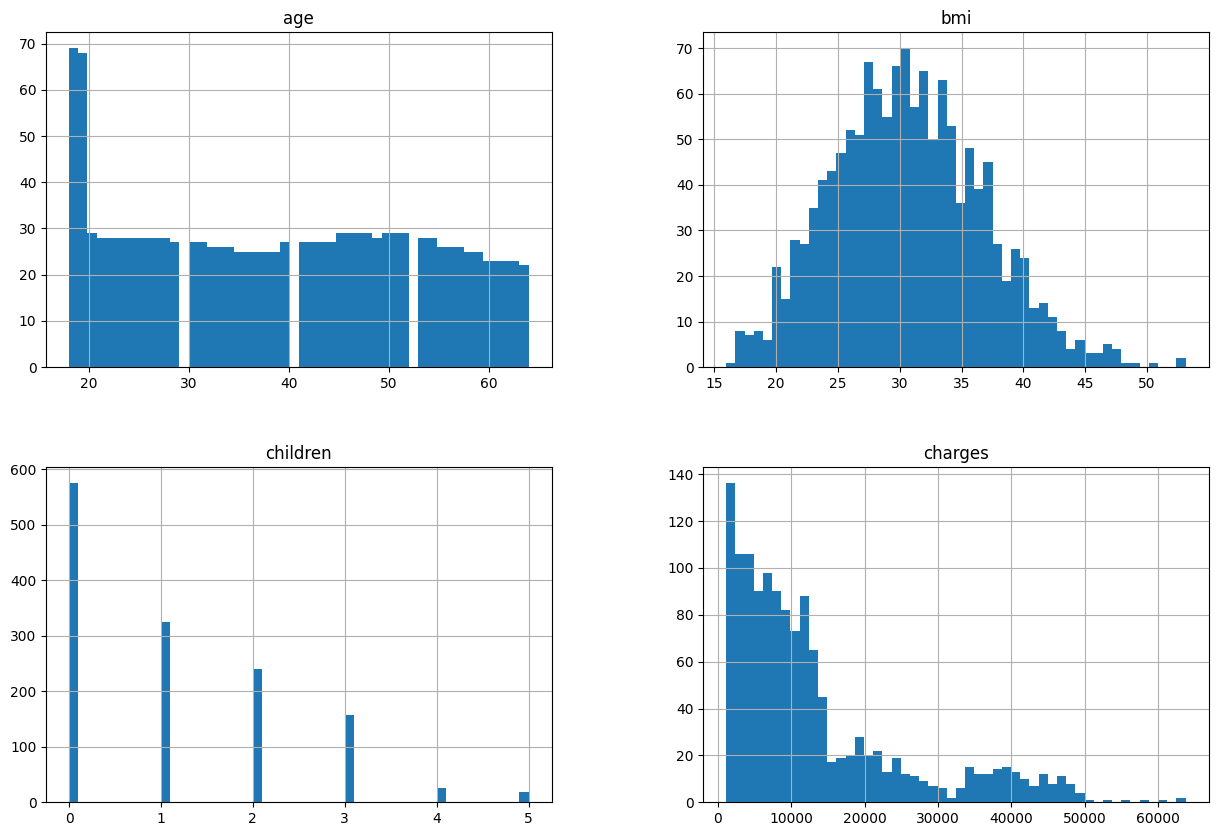

In [3]:
# Plot histograms of each feature
%matplotlib inline
data.hist(bins=50, figsize=(15,10))
plt.show()

### Initial observations

- The number of records decreases as the number of children increases.
- The dataset includes many policyholders under age 20.
- BMI is approximately normally distributed around 30.
- Most observed charges fall below $15,000.

In [4]:
# Perform a stratified split of the dataset into training and testing sets using the smoker feature for the split
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(data, data["smoker"]):
    print('Training samples: {}, testing samples: {}'
          .format(train_index.shape, test_index.shape))
    
    strat_train_set = data.loc[train_index]
    strat_test_set = data.loc[test_index]

Training samples: (1070,), testing samples: (268,)


In [5]:
# Compute correlations between training features and charges

# Select only numeric columns for correlation calculation
numeric_data = strat_train_set.select_dtypes(include=[float, int])

# Compute correlations between numeric features and 'charges'
correlation_matrix = numeric_data.corr()

# Sort feature correlations with charges
correlation_with_charges = correlation_matrix["charges"].sort_values(ascending=False)

print(correlation_with_charges)


charges     1.000000
age         0.291370
bmi         0.185565
children    0.061811
Name: charges, dtype: float64


### Correlation observations

Age has the strongest numeric correlation with charges, although the relationship is moderate. The categorical features are evaluated after encoding rather than in this numeric-only correlation matrix.

## Prepare the data

In [6]:
# Remove the output labels (charges) from the dataset and store them in another variable
train_data = strat_train_set.drop("charges", axis=1)  # Drop labels
data_labels = strat_train_set["charges"].copy()

X_test = strat_test_set.drop("charges", axis=1)
y_test = strat_test_set["charges"].copy()

In [7]:
# Check for missing values before applying the preparation pipeline.
print(train_data.isnull().sum())
print(strat_test_set.isnull().sum())
print(data_labels.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
dtype: int64
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
0


The dataset contains no missing values. The numeric pipeline retains median imputation so the preprocessing workflow remains robust if missing values appear in future data.

In [8]:
# Encode categorical features with one-hot encoding

from sklearn.preprocessing import OneHotEncoder

categories = train_data[['sex', 'smoker', 'region']]

# Initialize the OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)

# Apply OneHotEncoder to the categorical columns
cat_encoded = cat_encoder.fit_transform(categories)

print(cat_encoded)


[[0. 1. 1. ... 0. 0. 1.]
 [1. 0. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 ...
 [0. 1. 1. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 1. 0.]
 [1. 0. 1. ... 1. 0. 0.]]


In [9]:
from sklearn.base import BaseEstimator, TransformerMixin

# Create a class to select numerical or categorical columns 
# since Scikit-Learn doesn't handle DataFrames yet
class DataFrameSelector(BaseEstimator, TransformerMixin):
    def __init__(self, attribute_names):
        self.attribute_names = attribute_names
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X[self.attribute_names].values

In [10]:
# Prepare training and test features with a shared pipeline

from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
numeric_data = train_data.select_dtypes(include=[float, int])
num_attribs = list(numeric_data)
cat_attribs = ['sex', 'smoker', 'region']

# Pipeline for cleaning and preparing numerical features
num_pipeline = Pipeline([
    ('selector', DataFrameSelector(num_attribs)),
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

# Pipeline for preparing categorical features
cat_pipeline = Pipeline([
    ('selector', DataFrameSelector(cat_attribs)),
    ('cat_encoder', OneHotEncoder(sparse_output=False)),
])

# Combining both pipelines using FeatureUnion
full_pipeline = FeatureUnion(transformer_list=[
    ("num_pipeline", num_pipeline),
    ("cat_pipeline", cat_pipeline),
])

# Fit and transform the data
data_prepared = full_pipeline.fit_transform(train_data)
X_test_prepared = full_pipeline.fit_transform(X_test)

# Display the transformed data for the first row
print(data_prepared[0])
print(X_test_prepared[0])

[-1.00715695 -0.656649    1.56520739  0.          1.          1.
  0.          0.          0.          0.          1.        ]
[-0.60362731 -0.27760933  3.33442849  0.          1.          1.
  0.          1.          0.          0.          0.        ]


## Select, train and evaluate a model

The following section compares linear regression, decision-tree regression, and random-forest regression. Each model is trained on the training set and evaluated on the held-out test set using RMSE.

In [11]:
# Linear regression
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(data_prepared, data_labels)

# predict values for each sample in training set
data_predictions = lin_reg.predict(data_prepared)


from sklearn.metrics import mean_squared_error

# compute RMSE for training set (training error)
lin_mse = mean_squared_error(data_labels, data_predictions)
lin_rmse = np.sqrt(lin_mse)
print("On train: ", lin_rmse)

# Evaluate on the test set
lin_reg = LinearRegression()

lin_reg.fit(X_test_prepared, y_test)

# predict values for each sample in training set
X_predictions = lin_reg.predict(X_test_prepared)


from sklearn.metrics import mean_squared_error

# compute RMSE for training set (training error)
lin_mse = mean_squared_error(y_test, X_predictions)
lin_rmse = np.sqrt(lin_mse)
print("On test: ", lin_rmse)

On train:  6154.852330680004
On test:  5511.810370592451


In [12]:
# Decision Tree
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(data_prepared, data_labels)

data_predictions = tree_reg.predict(data_prepared)

tree_mse = mean_squared_error(data_labels, data_predictions)
tree_rmse = np.sqrt(tree_mse)
print("On train: ", tree_rmse)

# Evaluate on the test set
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_test_prepared, y_test)

data_predictions = tree_reg.predict(X_test_prepared)

tree_mse = mean_squared_error(y_test, data_predictions)
tree_rmse = np.sqrt(tree_mse)
print("On test: ", tree_rmse)

On train:  494.20598375812835
On test:  0.0


In [13]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

forest_reg = RandomForestRegressor(random_state=42, n_estimators=10)
forest_reg.fit(data_prepared, data_labels)

data_predictions = forest_reg.predict(data_prepared)

forest_mse = mean_squared_error(data_labels, data_predictions)
forest_rmse = np.sqrt(forest_mse)
print("On train: ", forest_rmse)

# Evaluate on the test set
forest_reg = RandomForestRegressor(random_state=42, n_estimators=10)
forest_reg.fit(X_test_prepared, y_test)

X_predictions = forest_reg.predict(X_test_prepared)

forest_mse = mean_squared_error(y_test, X_predictions)
forest_rmse = np.sqrt(forest_mse)
print("On test: ", forest_rmse)

On train:  2142.3287820585856
On test:  2219.5927974640995


### Model comparison

The decision tree achieves the lowest training error but shows clear overfitting. The random forest provides the strongest balance: substantially lower test error than linear regression without the decision tree's extreme training-test gap.